# FIG Quant Pod — Research Notebook

End-to-end walkthrough of `fig_quant`: bi-temporal PIT data, incremental signal validation, CANN pricing with CPCV, GARCH+EVT tail risk, and Bayesian capital sizing — with Plotly tearsheets exported as standalone HTML + PNG so they render on GitHub.

In [1]:
import pathlib
import numpy as np
import plotly.graph_objects as go
from IPython.display import Image, display

from fig_quant.data.signal_validation import validate_features
from fig_quant.models.cann import CANNRegressor
from fig_quant.models.cpcv import cpcv_year_splits
from fig_quant.risk.garch_evt import fit_garch11, conditional_sigma, fit_gpd_tail, gpd_var
from fig_quant.capital.bayesian_sizing import update_nig_posterior, expected_severity_lcb

OUTDIR = pathlib.Path("./output")
OUTDIR.mkdir(exist_ok=True)

# Set to False while developing locally (interactive plot); True before
# committing so GitHub renders the pre-exported PNG in the notebook diff.
FORCE_STATIC_FOR_GITHUB = True


def render(fig: go.Figure, name: str) -> None:
    """Exports `fig` to HTML+PNG and displays it notebook- and GitHub-safe."""
    html_path = OUTDIR / f"{name}.html"
    png_path = OUTDIR / f"{name}.png"
    fig.write_html(html_path, include_plotlyjs="cdn")
    try:
        fig.write_image(png_path, scale=2)
    except Exception as exc:
        print(f"Note: Live PNG export skipped ({exc}); checking for pre-rendered image.")

    if FORCE_STATIC_FOR_GITHUB and png_path.exists():
        display(Image(filename=str(png_path)))
    else:
        try:
            fig.show()
        except Exception:
            if png_path.exists():
                display(Image(filename=str(png_path)))
            else:
                raise


## 1. Signal validation: incremental IC / permutation / BHY

In [2]:
rng = np.random.default_rng(0)
n = 2000
groups = rng.integers(0, 50, size=n)
controls = np.column_stack([np.ones(n), rng.normal(size=n)])
alt_hazard_score = rng.normal(size=n)
random_noise_feature = rng.normal(size=n)
target = 0.45 * alt_hazard_score + 0.25 * controls[:, 1] + rng.normal(scale=0.5, size=n)

results = validate_features(
    {"alt_hazard_score": alt_hazard_score, "random_noise_feature": random_noise_feature},
    target, controls, groups, q=0.10, n_permutations=1000,
)
for r in results:
    print(f"{r.feature_name:24s} IC={r.incremental_ic:+.4f}  p={r.p_value:.4f}  rejected={r.rejected}")


alt_hazard_score         IC=+0.6548  p=0.0010  rejected=True
random_noise_feature     IC=+0.0210  p=0.3616  rejected=False


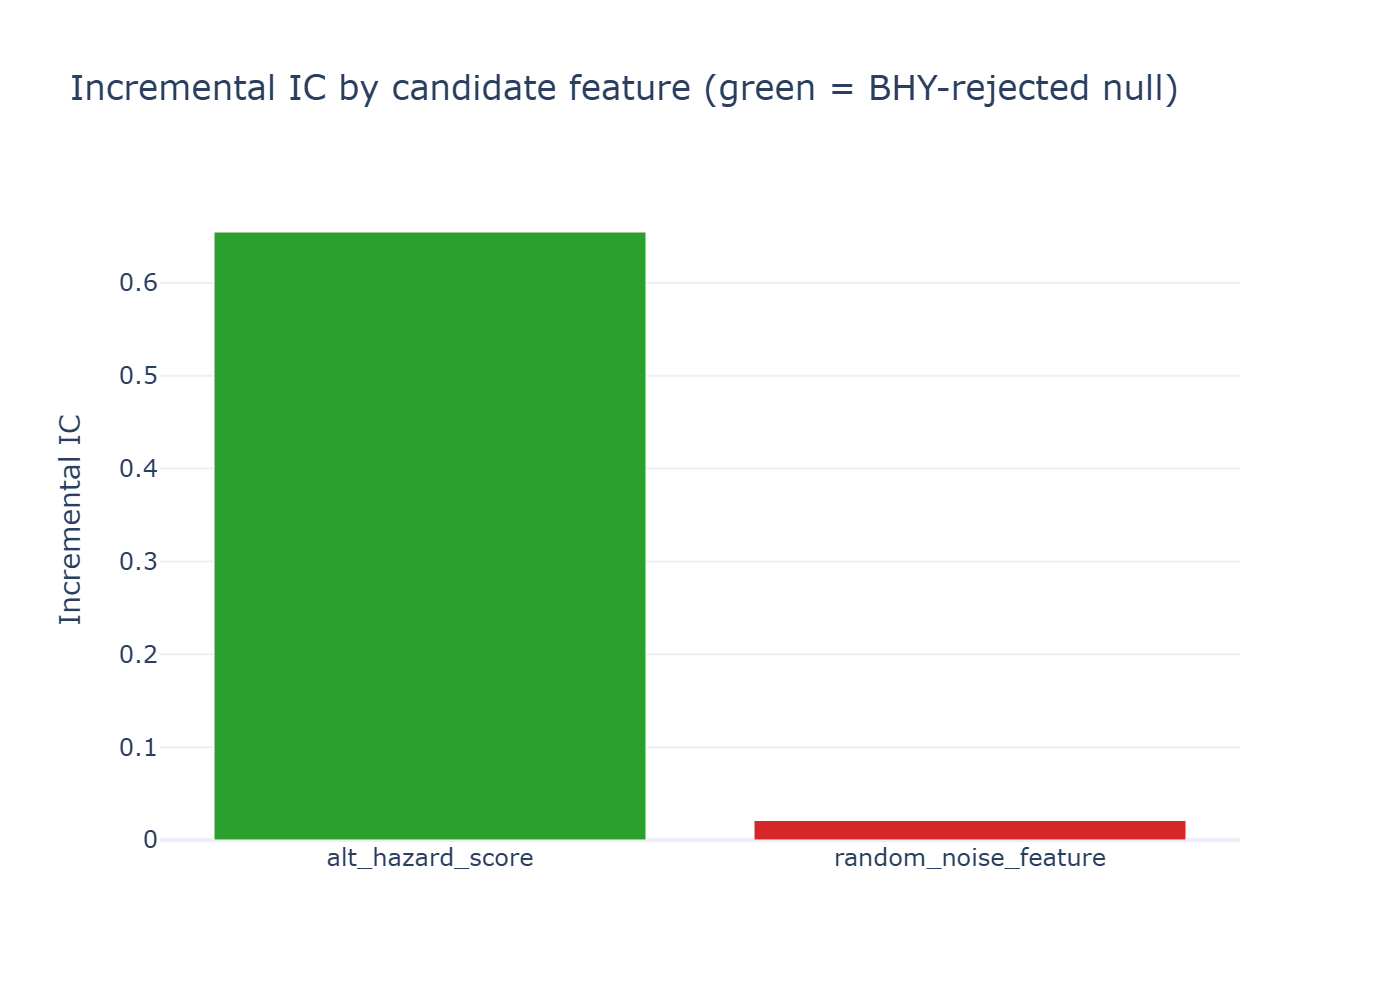

In [3]:
fig = go.Figure()
fig.add_bar(x=[r.feature_name for r in results], y=[r.incremental_ic for r in results],
            marker_color=["#2ca02c" if r.rejected else "#d62728" for r in results])
fig.update_layout(title="Incremental IC by candidate feature (green = BHY-rejected null)",
                   yaxis_title="Incremental IC", template="plotly_white")
render(fig, "signal_validation_ic")


## 2. CANN severity pricing

CANN in-sample MAE: 158.76


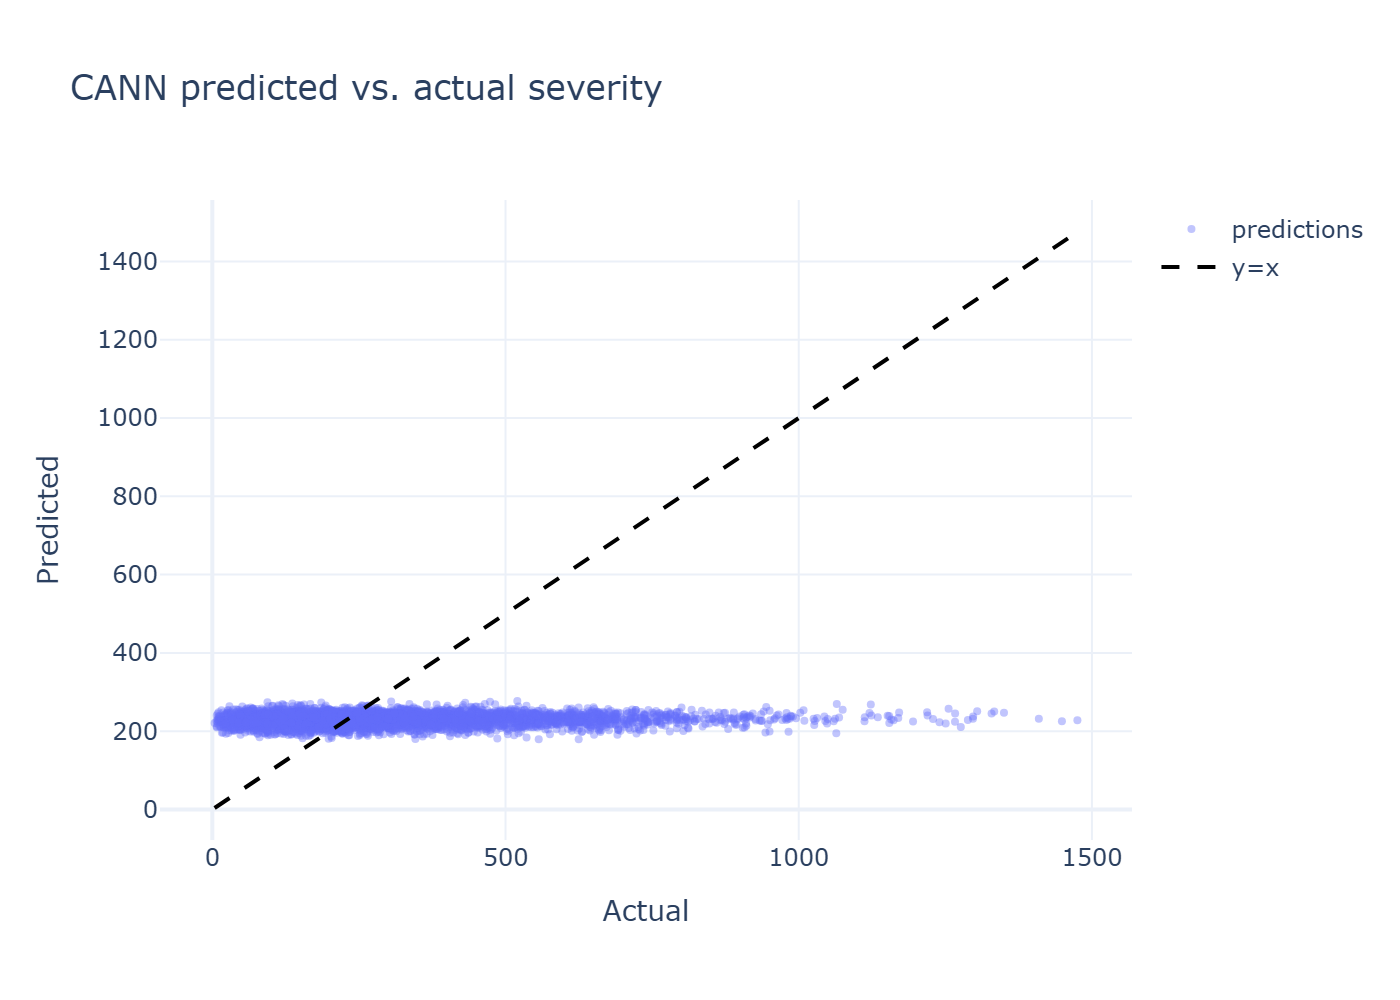

In [4]:
n_policy = 5000
x = rng.uniform(0.1, 2.0, size=(n_policy, 4))
severity = np.exp(0.4 * x[:, 0] + 0.2 * x[:, 1] - 0.1 * x[:, 2]) + rng.gamma(2.0, 150.0, size=n_policy)

model = CANNRegressor(hidden_dim=16, seed=1).fit(x, severity, epochs=400)
preds = model.predict(x)
mae = np.mean(np.abs(preds - severity))
print(f"CANN in-sample MAE: {mae:.2f}")

fig = go.Figure()
fig.add_scatter(x=severity, y=preds, mode="markers", marker=dict(size=4, opacity=0.4), name="predictions")
lo, hi = float(severity.min()), float(severity.max())
fig.add_scatter(x=[lo, hi], y=[lo, hi], mode="lines", line=dict(dash="dash", color="black"), name="y=x")
fig.update_layout(title="CANN predicted vs. actual severity", xaxis_title="Actual", yaxis_title="Predicted",
                   template="plotly_white")
render(fig, "cann_fit")


## 3. Combinatorial Purged Cross-Validation folds

In [5]:
folds = cpcv_year_splits([2021, 2022, 2023, 2024], n_test_groups=2, embargo=0)
for f in folds:
    print(f"test={f.test_years}  train={f.train_years}")


test=(2021, 2022)  train=(2023, 2024)
test=(2021, 2023)  train=(2022, 2024)
test=(2021, 2024)  train=(2022, 2023)
test=(2022, 2023)  train=(2021, 2024)
test=(2022, 2024)  train=(2021, 2023)
test=(2023, 2024)  train=(2021, 2022)


## 4. GARCH(1,1) + EVT conditional tail risk

GARCH params: omega=0.0752 alpha=0.1167 beta=0.8212
EVT 99% tail VaR (standardized units): 2.3419


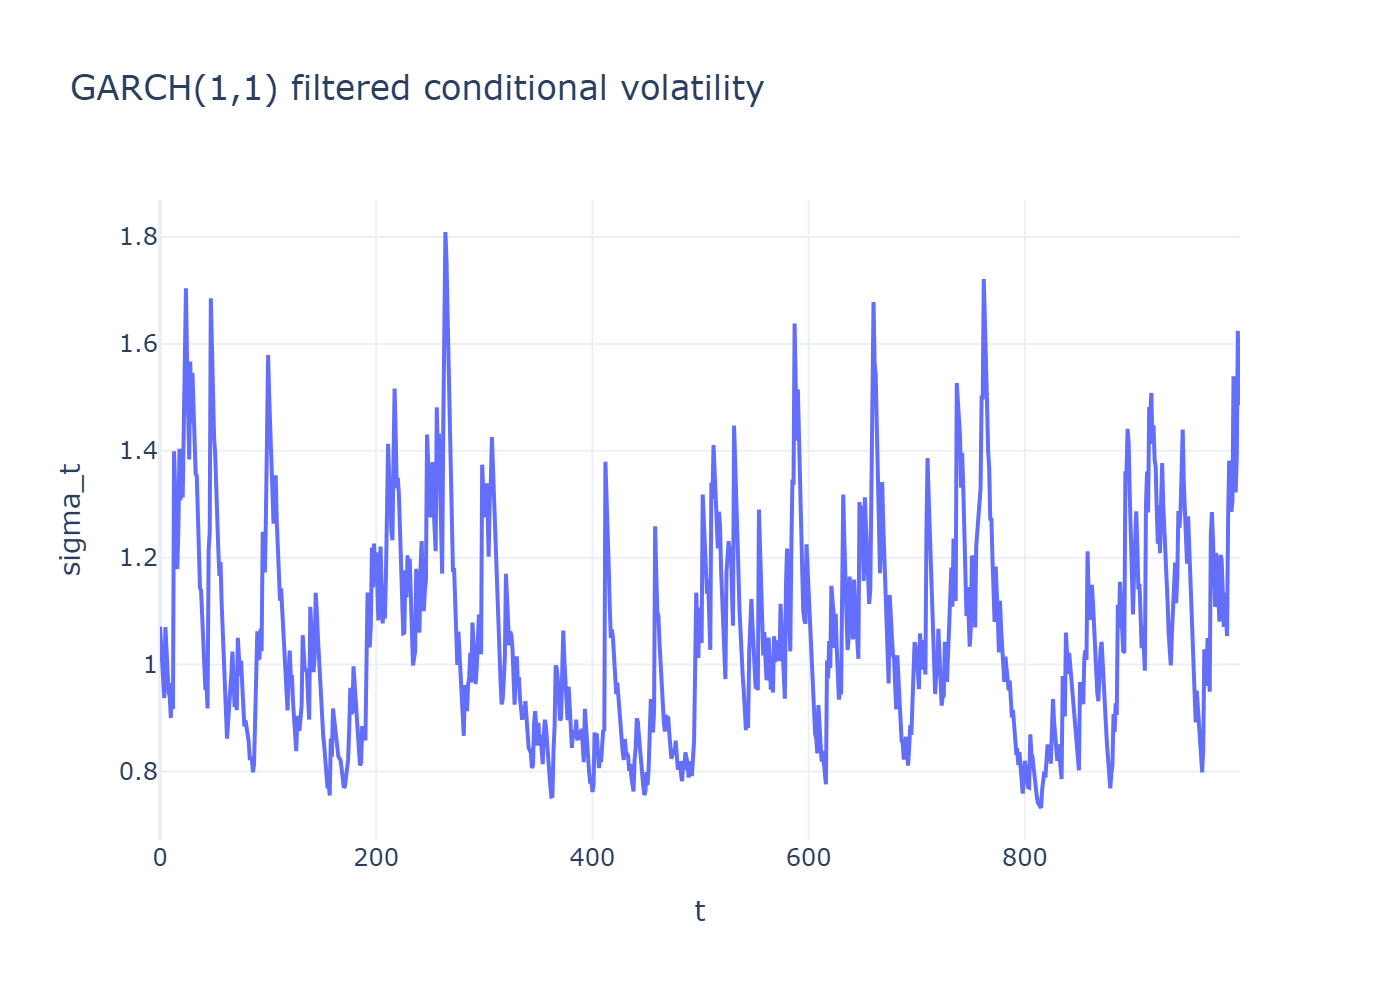

In [6]:
n_t = 1000
eps = np.empty(n_t)
sigma2 = 0.05 / (1 - 0.1 - 0.85)
for t in range(n_t):
    sigma2 = 0.05 + 0.1 * (eps[t-1]**2 if t > 0 else sigma2) + 0.85 * sigma2
    eps[t] = rng.normal(scale=np.sqrt(sigma2))

params = fit_garch11(eps)
sigma_t = conditional_sigma(eps, params)
standardized = eps / sigma_t
tail_fit = fit_gpd_tail(standardized, quantile=0.90)
var_99 = gpd_var(tail_fit, alpha=0.01)
print(f"GARCH params: omega={params.omega:.4f} alpha={params.alpha:.4f} beta={params.beta:.4f}")
print(f"EVT 99% tail VaR (standardized units): {var_99:.4f}")

fig = go.Figure()
fig.add_scatter(y=sigma_t, mode="lines", name="conditional sigma_t")
fig.update_layout(title="GARCH(1,1) filtered conditional volatility", xaxis_title="t", yaxis_title="sigma_t",
                   template="plotly_white")
render(fig, "garch_sigma_path")


## 5. Bayesian small-sample severity sizing

In [7]:
log_sev = np.log(np.array([480.0, 620.0, 510.0, 700.0, 455.0]))
posterior = update_nig_posterior(log_sev)
lcb = expected_severity_lcb(posterior, confidence=0.95)
print(f"Posterior mean (log-severity): {posterior.mu:.4f}")
print(f"Conservative expected-severity LCB: {lcb:.2f}")


Posterior mean (log-severity): 5.2515
Conservative expected-severity LCB: 537.64
